# Basket Analysis

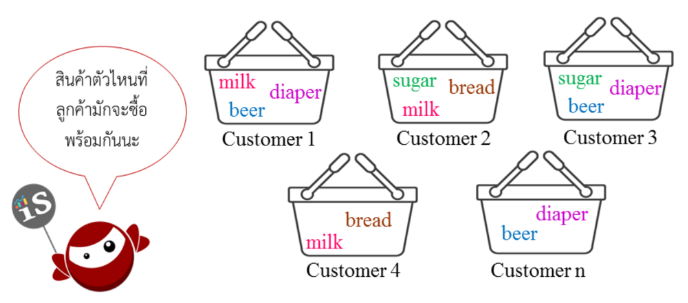

- by [<img src="http://rasbt.github.io/mlxtend/img/logo.png" height="32">](http://rasbt.github.io/mlxtend/)

# Apriori Algorithm

อัลกอริทึม Apriori เป็นเทคนิคที่ถูกนำมาใช้ในการขุดหา association rule ในฐานข้อมูลที่มีการทำธุรกรรม มีประสิทธิภาพในการระบุชุดรายการที่เป็นที่นิยมและสร้าง association rule อัลกอริทึมนี้ใช้วิธีการ "bottom-up" และมีพื้นฐานบนหลัก Apriori

**Key Steps:**

1. **Generate Frequent Itemsets:**
   อัลกอริทึมเริ่มด้วยการค้นหา frequent itemsets ซึ่งเป็นชุดของสินค้าที่เกิดขึ้นพร้อมกันในการทำธุรกรรมมากกว่า minimum support threshold

2. **Join Step:**
   ในขั้นตอนนี้อัลกอริทึมสร้าง candidate itemsets โดยการรวม frequent itemsets จากการทำซ้ำก่อนหน้า

3. **Prune Step:**
   candidate itemsets ที่ไม่ตรงตามเกณฑ์ minimum support threshold จะถูกตัดทิ้งเพื่อลดพื้นที่ในการค้นหา

4. **Repeat the Join and Prune Steps:**
   อัลกอริทึมทำซ้ำในกระบวนการรวมและตัดจนกว่าจะไม่สามารถสร้าง frequent itemsets ใหม่ได้

5. **Generate Association Rules:**
   เมื่อได้รับ frequent itemsets แล้ว association rules จะถูกสร้างขึ้นจากชุดรายการเหล่านี้ กฎประกอบด้วย antecedent (ด้านซ้าย) และส่วน consequent (ด้านขวา)

6. **Calculate Metrics:**
   ตัวชี้วัดเช่น support, confidence, และ lift ถูกคำนวณสำหรับแต่ละ association rule เพื่อวัดความแข็งแกร่งและความสำคัญของความสัมพันธ์

![Apriori Algorithm](https://www.codeproject.com/KB/recipes/AprioriAlgorithm/4-Example.JPG)

(image from: https://www.codeproject.com/Articles/70371/Apriori-Algorithm)

## สร้าง DataFrame

- เรียกใช้ `pandas`

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
import pandas as pd
transactions = [['Laptop', 'Printer', 'Tablet', 'Headset'],
           ['Printer', 'Monitor', 'Tablet'],
           ['Laptop', 'Printer', 'Tablet', 'Headset'],
           ['Laptop', 'Monitor', 'Tablet', 'Headset'],
           ['Printer', 'Monitor', 'Tablet', 'Headset'],
           ['Printer', 'Tablet', 'Headset'],
           ['Monitor', 'Tablet'],
           ['Laptop', 'Printer', 'Monitor'],
           ['Laptop', 'Tablet', 'Headset'],
           ['Printer', 'Tablet']]
transactions

[['Laptop', 'Printer', 'Tablet', 'Headset'],
 ['Printer', 'Monitor', 'Tablet'],
 ['Laptop', 'Printer', 'Tablet', 'Headset'],
 ['Laptop', 'Monitor', 'Tablet', 'Headset'],
 ['Printer', 'Monitor', 'Tablet', 'Headset'],
 ['Printer', 'Tablet', 'Headset'],
 ['Monitor', 'Tablet'],
 ['Laptop', 'Printer', 'Monitor'],
 ['Laptop', 'Tablet', 'Headset'],
 ['Printer', 'Tablet']]

## ปรับรูปแบบ transactions

transactions จะต้องอยู่ในรูปแบบของตาราง ที่แต่ละแถวแสดงการมี (True) หรือไม่มี (False) สินค้าใน 1 รายการของ transaction
- ใช้ `TransactionEncoder`  
from mlxtend.preprocessing import TransactionEncoder

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te.fit(transactions)
# fit() จะเรียนรู้ unique items ทั้งหมด ที่เจอใน transactions
# หลังจาก fit() แล้ว te จะจำได้ว่ามี items คือ {Headset, Laptop, Monitor, Printer, Tablet}

TransactionEncoder()

In [ ]:
te.columns_

['Headset', 'Laptop', 'Monitor', 'Printer', 'Tablet']

In [ ]:
t_encode = te.transform(transactions)
t_encode

array([[ True,  True, False,  True,  True],
       [False, False,  True,  True,  True],
       [ True,  True, False,  True,  True],
       [ True,  True,  True, False,  True],
       [ True, False,  True,  True,  True],
       [ True, False, False,  True,  True],
       [False, False,  True, False,  True],
       [False,  True,  True,  True, False],
       [ True,  True, False, False,  True],
       [False, False, False,  True,  True]])

In [ ]:
df = pd.DataFrame(t_encode, columns=te.columns_)
# columns: This parameter is used to provide column names in the dataframe.
df

,Headset,Laptop,Monitor,Printer,Tablet
0,True,True,False,True,True
1,False,False,True,True,True
2,True,True,False,True,True
3,True,True,True,False,True
4,True,False,True,True,True
5,True,False,False,True,True
6,False,False,True,False,True
7,False,True,True,True,False
8,True,True,False,False,True
9,False,False,False,True,True


## Apriori

หา frequent itemsets ด้วย Apriori
- เรียกใช้ `apriori` library

from mlxtend.frequent_patterns import apriori

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
from mlxtend.frequent_patterns import apriori

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fia = apriori(df, min_support=0.3, use_colnames=True)
fia

,support,itemsets
0,0.6,(Headset)
1,0.5,(Laptop)
2,0.5,(Monitor)
3,0.7,(Printer)
4,0.9,(Tablet)
5,0.4,"(Laptop, Headset)"
6,0.4,"(Headset, Printer)"
7,0.6,"(Headset, Tablet)"
8,0.3,"(Laptop, Printer)"
9,0.4,"(Laptop, Tablet)"


- ผลลัพธ์ที่ได้จะเป็น DataFrame
- สามารถปรับแต่งได้ตามต้องการ เช่น เพิ่ม Series ที่แสดงจำนวนรายการใน itemset

In [ ]:
fia['length'] = fia['itemsets'].apply(lambda x: len(x)) # ใช้ function len() กับทุกค่าของ itemsets เพื่อนับจำนวน items ที่อยู่ในแต่ละเซต
fia

,support,itemsets,length
0,0.6,(Headset),1
1,0.5,(Laptop),1
2,0.5,(Monitor),1
3,0.7,(Printer),1
4,0.9,(Tablet),1
5,0.4,"(Laptop, Headset)",2
6,0.4,"(Headset, Printer)",2
7,0.6,"(Headset, Tablet)",2
8,0.3,"(Laptop, Printer)",2
9,0.4,"(Laptop, Tablet)",2


- สามารถค้นหา itemsets ที่ต้องการได้

In [ ]:
fia[(fia['length'] == 2)]

,support,itemsets,length
5,0.4,"(Laptop, Headset)",2
6,0.4,"(Headset, Printer)",2
7,0.6,"(Headset, Tablet)",2
8,0.3,"(Laptop, Printer)",2
9,0.4,"(Laptop, Tablet)",2
10,0.3,"(Printer, Monitor)",2
11,0.4,"(Tablet, Monitor)",2
12,0.6,"(Printer, Tablet)",2


In [ ]:
fia[(fia['length'] == 2) & (fia['support'] >= 0.4) ]

,support,itemsets,length
5,0.4,"(Laptop, Headset)",2
6,0.4,"(Headset, Printer)",2
7,0.6,"(Headset, Tablet)",2
9,0.4,"(Laptop, Tablet)",2
11,0.4,"(Tablet, Monitor)",2
12,0.6,"(Printer, Tablet)",2


In [ ]:
fia[ fia['itemsets'] == {'Printer', 'Laptop'} ]

,support,itemsets,length
8,0.3,"(Laptop, Printer)",2


In [ ]:
fia[[{'Printer', 'Laptop'}.issubset(fi) for fi in fia['itemsets']]]

,support,itemsets,length
8,0.3,"(Laptop, Printer)",2


# Association Rules

Association rules เป็นการแสดงความสัมพันธ์ทางตรรกะระหว่างสินค้าโดยขึ้นอยู่กับการเกิดขึ้นร่วมกันในการทำธุรกรรม กฎเหล่านี้ช่วยให้มีความเข้าใจในพฤติกรรมและความชอบของลูกค้า เพื่อช่วยธุรกิจในการตัดสินใจอย่างมีข้อมูล

**Format of Association Rule:**
- Antecedent (Left-hand side) -> Consequent (Right-hand side)

## Metrics

**1. Support:**

Support is the proportion of transactions that contain both the antecedent and the consequent of an association rule.

```
Support(A->B) = (Number of Transactions containing A and B) / (Total Number of Transactions)
```

**Example:**
Suppose out of 100 transactions, 40 contain both items A and B.
```
Support(A->B) = 40 / 100 = 0.4
```

**2. Confidence:**

Confidence is the probability of finding the consequent in a transaction given that the antecedent is already present in that transaction.

```
Confidence(A->B) = (Number of Transactions containing A and B) / (Number of Transactions containing A)
```

**Example:**
Out of the 60 transactions containing item A, 40 also contain item B.
```
Confidence(A->B) = 40 / 60 = 0.6667
```

**3. Lift:**

Lift measures the ratio of observed support to expected support for an association rule. It indicates how much more likely the items in the antecedent and consequent are to be bought together compared to if they were bought independently.

```
Lift(A->B) = Support(A->B) / (Support(A) * Support(B))
```

**Example:**

Suppose we have the following information:

- Total number of transactions: 1000
- Transactions containing item A: 600
- Transactions containing item B: 400
- Transactions containing both A and B: 200

**Calculate Lift for Rule A->B:**

1. Calculate Support:
   - Support(A) = Transactions containing A / Total transactions = 600 / 1000 = 0.6
   - Support(B) = Transactions containing B / Total transactions = 400 / 1000 = 0.4
   - Support(A->B) = Transactions containing A and B / Total transactions = 200 / 1000 = 0.2

2. Calculate Lift:
   - Lift(A->B) = Support(A->B) / (Support(A) * Support(B))
   - Lift(A->B) = 0.2 / (0.6 * 0.4) = 0.8333

**Interpretation:**

- หาก Lift(A->B) = 1 แสดงว่าการเกิดของ A และ B ไม่เกี่ยวข้องกัน
- หาก Lift(A->B) > 1 แสดงว่าการเกิดของ A เพิ่มโอกาสในการซื้อ B
- หาก Lift(A->B) < 1 แสดงว่าการเกิดของ A ลดโอกาสในการซื้อ B

ในตัวอย่างนี้ Lift(A->B) มากกว่า 1 ซึ่งแสดงถึงการเชื่อมโยงบวกระหว่างรายการ A และ B นี้ เป็นการบ่งชี้ว่าลูกค้าที่ซื้อรายการ A มีโอกาสที่จะซื้อรายการ B ด้วย และการมี A เพิ่มโอกาสในการซื้อ B

- สร้างจาก frequent itemsets
- เรียกใช้ `association_rules` library

- กำหนดเกณฑ์ในการพิจารณากฏ
- supported metrics are 'support', 'confidence', 'lift', 'leverage', and 'conviction'
  - support(A->C) = support(A+C) [aka 'support'], range: [0, 1]
    
  - confidence(A->C) = support(A+C) / support(A), range: [0, 1]
    
  - lift(A->C) = confidence(A->C) / support(C), range: [0, inf]
    
  - leverage(A->C) = support(A->C) - support(A)*support(C), range: [-1, 1]
    
  - conviction = [1 - support(C)] / [1 - confidence(A->C)], range: [0, inf]

In [ ]:
from mlxtend.frequent_patterns import association_rules

In [ ]:
rules = association_rules(fia)
#rules = association_rules(fia, metric="confidence", min_threshold=0.5)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Laptop),(Headset),0.5,0.6,0.4,0.800000,1.333333,1.0,0.10,2.0,0.500000,0.571429,0.500000,0.733333
1,(Headset),(Tablet),0.6,0.9,0.6,1.000000,1.111111,1.0,0.06,inf,0.250000,0.666667,1.000000,0.833333
2,(Laptop),(Tablet),0.5,0.9,0.4,0.800000,0.888889,1.0,-0.05,0.5,-0.200000,0.400000,-1.000000,0.622222
3,(Monitor),(Tablet),0.5,0.9,0.4,0.800000,0.888889,1.0,-0.05,0.5,-0.200000,0.400000,-1.000000,0.622222
4,(Printer),(Tablet),0.7,0.9,0.6,0.857143,0.952381,1.0,-0.03,0.7,-0.142857,0.600000,-0.428571,0.761905
5,"(Laptop, Headset)",(Tablet),0.4,0.9,0.4,1.000000,1.111111,1.0,0.04,inf,0.166667,0.444444,1.000000,0.722222
6,"(Laptop, Tablet)",(Headset),0.4,0.6,0.4,1.000000,1.666667,1.0,0.16,inf,0.666667,0.666667,1.000000,0.833333
7,(Laptop),"(Headset, Tablet)",0.5,0.6,0.4,0.800000,1.333333,1.0,0.10,2.0,0.500000,0.571429,0.500000,0.733333
8,"(Headset, Printer)",(Tablet),0.4,0.9,0.4,1.000000,1.111111,1.0,0.04,inf,0.166667,0.444444,1.000000,0.722222
